In [2]:
import pandas as pd 
import optuna
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [3]:
df = pd.read_csv('../data/Bank_Churn.csv')

In [4]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# usunięcie zbędnych kolumn do modelowania 

df = df.drop(columns= ['CustomerId', 'Surname'])

In [6]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

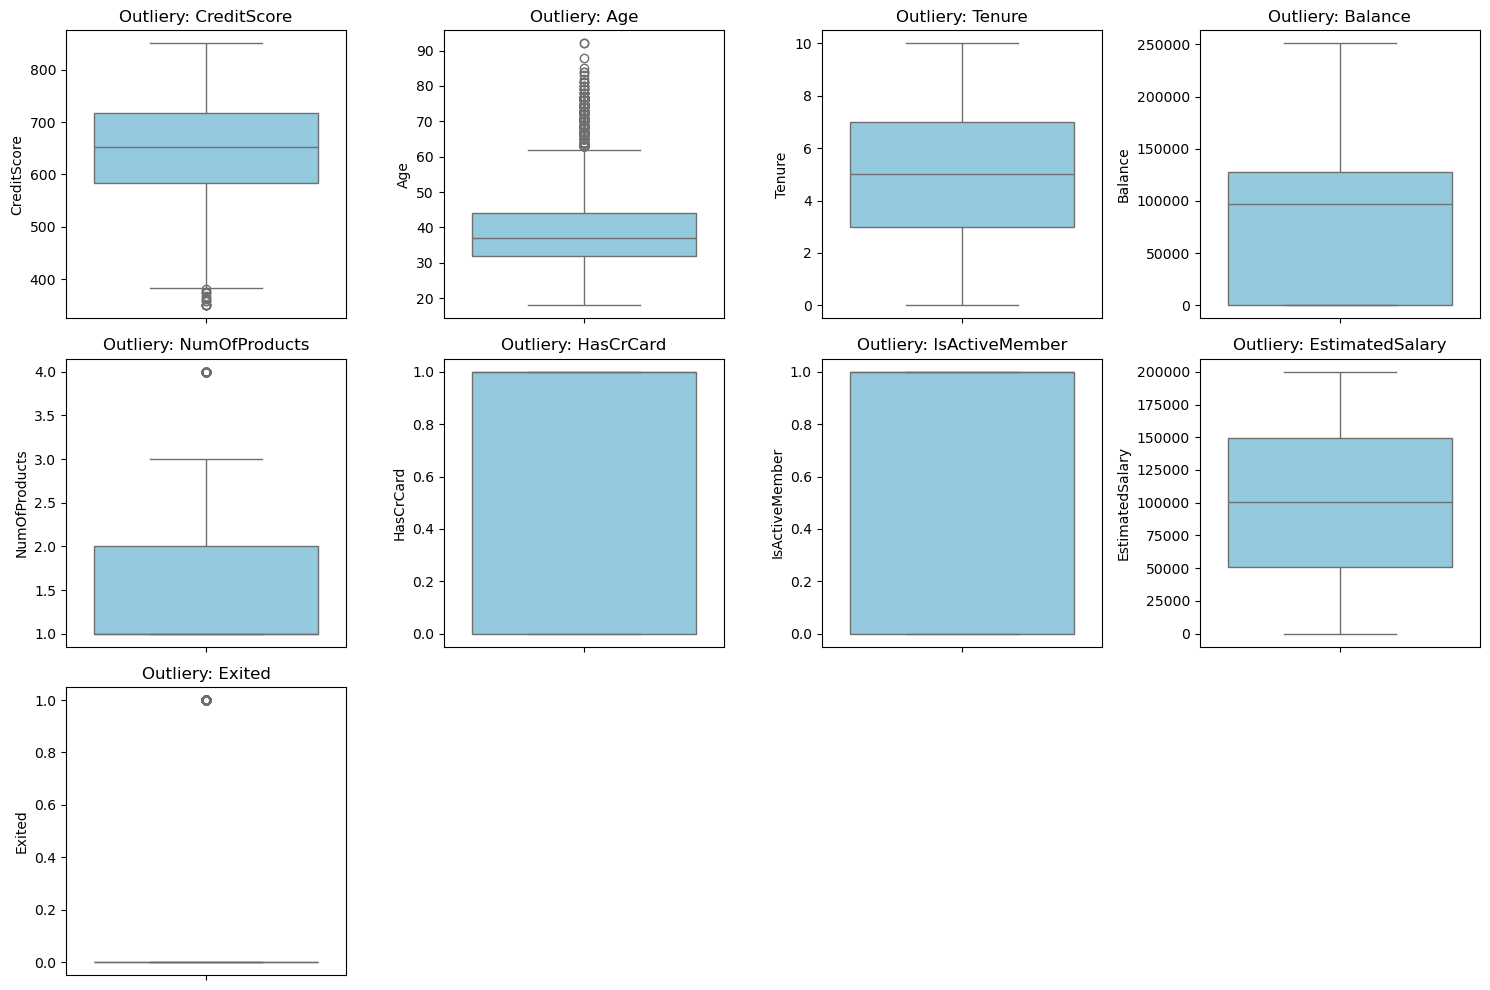

In [9]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Tworzymy siatkę wykresów
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols):
    plt.subplot(3, 4, i + 1) 
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliery: {col}')
    plt.tight_layout()

plt.show()

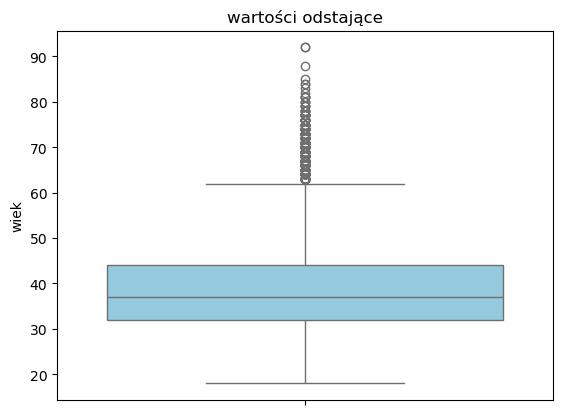

In [10]:
# W tym wypadku nie będziemy usuwać outlierów, ze względu na to że nie jest to błąd pomiaru 

plt.Figure(figsize=(8,6))

sns.boxplot(y=df['Age'], color='skyblue')
plt.title('wartości odstające')
plt.ylabel('wiek')
plt.show()

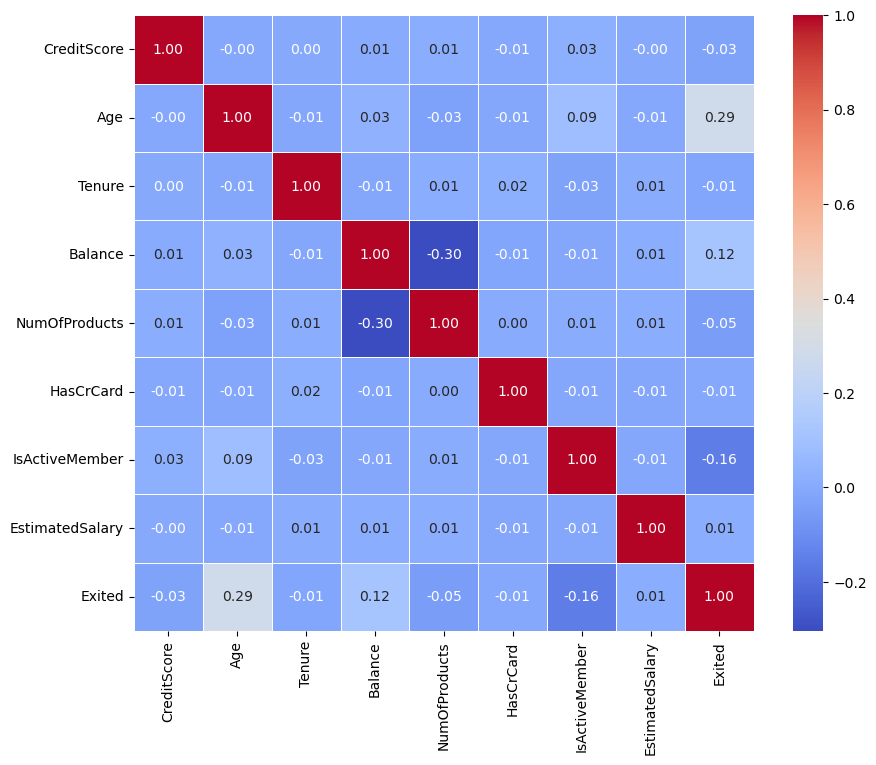

In [11]:
#Sprawdzamy korelacje naszych danych


num_corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    num_corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5)

plt.show()

In [12]:
# sprawadzamy jak z balansowane są klasy 

df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [13]:
target = 'Exited'

X = df.drop(columns= 'Exited')
y = df[target]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
#dzielimy dane na dane numeryczne i kategoryczne

num_cols_m = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols_m = X.select_dtypes(include=['object', 'string']).columns

In [16]:
num_proccesor = SkPipeline([
    ('impuer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
cat_proccesor = SkPipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder())
])


In [20]:
# łączymy dane za pomocą columns transformera 

preprocces = ColumnTransformer([
    ('num_procesor', num_proccesor, num_cols_m),
    ('cat_procesor', cat_proccesor, cat_cols_m)
])

In [21]:
# inicjujemy nasz model 

model_xgb = XGBClassifier(n_estimators = 100 , random_state = 42)

In [22]:
#  łączymy całość w Pipeline

pipeline = SkPipeline([
    ('procesowanie', preprocces),
    ('model_xgb', model_xgb)
])

In [23]:
# trenujemy model 

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [24]:
cm = confusion_matrix(y_test, y_pred)
print("Raport klasyfikacji :")
print(classification_report(y_test, y_pred))
print("Macierz pomyłek:")
print(cm)

Raport klasyfikacji :
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1607
           1       0.69      0.50      0.58       393

    accuracy                           0.86      2000
   macro avg       0.79      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000

Macierz pomyłek:
[[1521   86]
 [ 198  195]]


Jak możemy zauważyć model ma problem z 'wyłapaniem' osób odchodzących ze względu na niezbalansowane dane, dlatego użyjemy metody Smote.

In [25]:
pipeline_borderline = ImbPipeline([
    ('preprocessor', preprocces),
    ('smote', BorderlineSMOTE(random_state=42)),
    ('model', model_xgb)
])

In [26]:
pipeline_borderline.fit(X_train, y_train)
y_pred_border = pipeline_borderline.predict(X_test)

In [27]:
cmb = confusion_matrix(y_test, y_pred_border)

print("Raport klasyfikacji (Borderline-SMOTE):")
print(classification_report(y_test, y_pred_border))
print("Macierz pomyłek:")
print(cmb)

Raport klasyfikacji (Borderline-SMOTE):
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1607
           1       0.62      0.58      0.60       393

    accuracy                           0.85      2000
   macro avg       0.76      0.75      0.75      2000
weighted avg       0.84      0.85      0.84      2000

Macierz pomyłek:
[[1464  143]
 [ 164  229]]


In [28]:
def objective(trial):
    
    param = {
        'smote__sampling_strategy': trial.suggest_float('smote__sampling_strategy', 0.5, 1.0),
        'model__max_depth': trial.suggest_int('model__max_depth', 3, 10),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.3, log=True),
        'model__n_estimators': trial.suggest_int('model__n_estimators', 100, 500),
        'model__subsample': trial.suggest_float('model__subsample', 0.5, 1.0),
    }

    
    pipeline_borderline.set_params(**param)

    #Sprawdzamy model (Scoring dajemy na recall żeby skupić sie osobach które odchodzą)
    
    score = cross_val_score(pipeline_borderline, X_train, y_train, cv=3, scoring='recall').mean()
    
    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) 

print("Najlepszy wynik Recall:", study.best_value)
print("Najlepsze parametry:", study.best_params)

[I 2026-04-10 21:27:15,990] A new study created in memory with name: no-name-80b86de0-9487-464f-9882-309029355ebe
[I 2026-04-10 21:27:17,061] Trial 0 finished with value: 0.546228710462287 and parameters: {'smote__sampling_strategy': 0.5135256281029461, 'model__max_depth': 7, 'model__learning_rate': 0.06335265751352312, 'model__n_estimators': 224, 'model__subsample': 0.5557292897569351}. Best is trial 0 with value: 0.546228710462287.
[I 2026-04-10 21:27:18,056] Trial 1 finished with value: 0.5577858880778589 and parameters: {'smote__sampling_strategy': 0.9445416749678311, 'model__max_depth': 8, 'model__learning_rate': 0.07757734885719794, 'model__n_estimators': 162, 'model__subsample': 0.8945582147342708}. Best is trial 1 with value: 0.5577858880778589.
[I 2026-04-10 21:27:19,642] Trial 2 finished with value: 0.5894160583941606 and parameters: {'smote__sampling_strategy': 0.657626746851512, 'model__max_depth': 8, 'model__learning_rate': 0.01745553173866859, 'model__n_estimators': 293, 

Najlepszy wynik Recall: 0.73661800486618
Najlepsze parametry: {'smote__sampling_strategy': 0.9987201376810595, 'model__max_depth': 3, 'model__learning_rate': 0.023110909177714904, 'model__n_estimators': 151, 'model__subsample': 0.6956880393800676}


In [ ]:
# Ustawiamy najlepsze znalezione  parametry 

pipeline_borderline.set_params(**study.best_params)
pipeline_borderline.fit(X_train, y_train)

In [30]:
y_pred_standard = pipeline_borderline.predict(X_test)


print("Raport klasyfikacji :")
print(classification_report(y_test, y_pred_standard))

print("Macierz pomyłek:")
print(confusion_matrix(y_test, y_pred_standard))

Raport klasyfikacji :
              precision    recall  f1-score   support

           0       0.93      0.78      0.85      1607
           1       0.46      0.78      0.58       393

    accuracy                           0.78      2000
   macro avg       0.70      0.78      0.71      2000
weighted avg       0.84      0.78      0.80      2000

Macierz pomyłek:
[[1249  358]
 [  87  306]]


Dzięki zastosowaniu optymalizacji hiperparametrów udało się podnieść czułość modelu (Recall) z 0.58 do 0.77 przy zachowaniu akceptowalnego poziomu precyzji. Oznacza to, że model skutecznie identyfikuje ponad 3/4 klientów zagrożonych odejściem, co czyni go wartościowym narzędziem w strategii na zatrzymanie klienta w  banku.

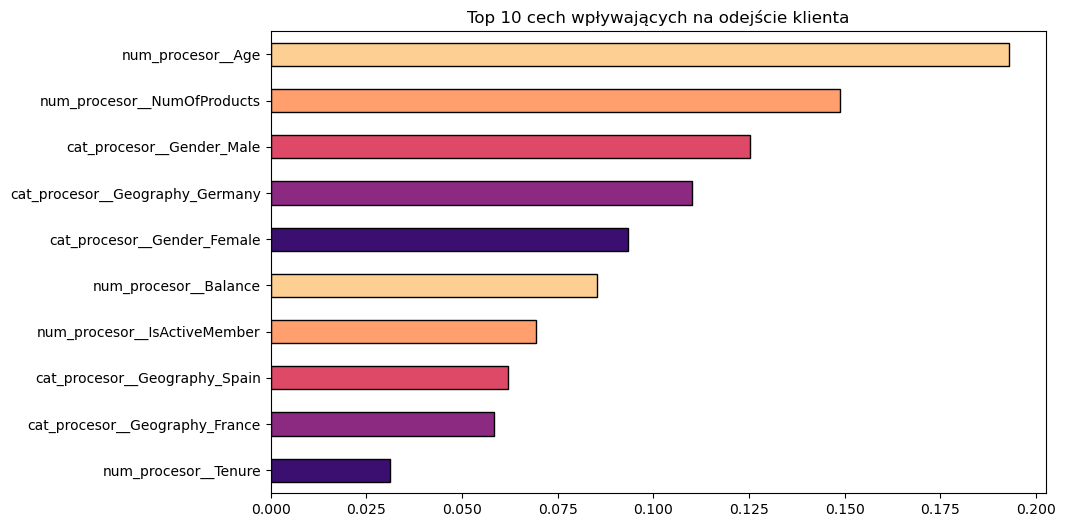

In [31]:
importances = pipeline_borderline.named_steps['model'].feature_importances_
features = pipeline_borderline.named_steps['preprocessor'].get_feature_names_out()

# tworzymy  wykres  przedtawiający 10 najważniejszych cech dla modelu
plt.figure(figsize=(10, 6))
pd.Series(importances, index=features).sort_values().tail(10).plot(
    kind='barh',
    color=plt.cm.magma([0.2, 0.4, 0.6, 0.8, 0.9]),
    edgecolor = 'black')
plt.title("Top 10 cech wpływających na odejście klienta")
plt.savefig('../images/top_10_model.png', dpi=300, bbox_inches='tight')
plt.show()